# Eigenstate–Fixed Point Correspondence

## An Investigation into the Connection Between Fixed-Point Dynamics and Quantum Eigenstates

**Author:** Keenan M Stone  
**Date started:** May 2017 (original scripts), April 2026 (this notebook)  
**Status:** Exploratory

---

## 1. Motivation and Background

### 1.1 The Core Intuition

The eigenvalue equation $\hat{A}|\psi\rangle = \lambda|\psi\rangle$ says: an operator acts on a state and returns *the same state* (up to scaling). In **projective Hilbert space** — where we identify $|\psi\rangle \sim c|\psi\rangle$ — this is exactly the definition of a **fixed point**. The eigenvalue $\lambda$ plays the role of $f'(x^*)$ at the fixed point, encoding its stability.

This suggests a dictionary:

| Fixed-point dynamics | Quantum eigenvalue problem |
|---|---|
| $f(x^*) = x^*$ | $\hat{A}|\psi\rangle = \lambda|\psi\rangle$ |
| $|f'(x^*)| < 1$: stable (attracting) | $|\lambda|$ largest: power method converges |
| $|f'(x^*)| > 1$: unstable (repelling) | $|\lambda|$ not largest: power method diverges |
| Alpha-transform $g = \alpha f + (1-\alpha)x$ | Relaxed iteration / spectral shift |
| Bifurcation in parameter $a$ | Spectral phase transitions as potential varies |

### 1.2 Why This Might Be More Than an Analogy

Several concrete algorithms already embody this connection without making it explicit:

- **Power iteration** converges to the eigenstate with largest $|\lambda|$ — the most "stable" fixed point of the projective map $|x\rangle \mapsto \hat{A}|x\rangle / \|\hat{A}|x\rangle\|$
- **Inverse power iteration with shift** $(\hat{A} - \sigma I)^{-1}$ converges to the eigenstate *nearest* $\sigma$ — this is fixed-point iteration with a *modified stability landscape*
- **Spectral shooting methods** find eigenvalues as zeros of a boundary mismatch — a *root-finding* problem that is itself a fixed-point problem

### 1.3 The Alpha-Transform (Original Work, 2017)

In the original Petrification scripts, an alpha-transform was used to convert unstable fixed points to stable ones:

$$g(x) = \alpha f(x) + (1-\alpha)x$$

The optimal $\alpha$ is computed from the extremal slope of $f$:
- If $f'_{\max} > 1$: $\alpha = \frac{2}{1 - f'_{\max}}$
- If $f'_{\min} < -1$: $\alpha = \frac{2}{1 - f'_{\min}}$

This was applied to the logistic map and Migdal-Kadanoff renormalization map. The question is: **can this technique be applied to the quantum eigenvalue problem via Turbiner's nonlinearization?**

### 1.4 Turbiner's Nonlinearization

A.V. Turbiner showed that the substitution $\psi(x) = \exp\!\left(-\int^x y(t)\,dt\right)$ converts the linear Schrödinger equation

$$-\frac{\hbar^2}{2m}\psi'' + V(x)\psi = E\psi$$

into the nonlinear **Riccati-Bloch equation** (in natural units $\hbar = m = 1$):

$$y'(x) = y(x)^2 - 2V(x) + 2E$$

The eigenvalue $E$ is determined by the condition that $y(x)$ remains *regular* (no singularities). This gives a natural fixed-point characterization of eigenvalues: **they are the parameter values for which a nonlinear dynamical system has bounded trajectories.**

## 2. References

### Primary Sources

1. **Turbiner, A.V.** "The eigenvalue spectrum in quantum mechanics and the nonlinearization procedure." *Soviet Physics Uspekhi* 27.9 (1984): 668–694.  
   *Key result:* Riccati-Bloch nonlinearization; logarithmic substitution converts linear eigenvalue problems to nonlinear first-order ODEs.

2. **Turbiner, A.V.** "Quasi-exactly-solvable problems and sl(2) algebra." *Communications in Mathematical Physics* 118.3 (1988): 467–474.  
   *Key result:* Lie-algebraic approach to spectral problems; classification of quasi-exactly-solvable potentials.

3. **Turbiner, A.V.** "One-dimensional quasi-exactly solvable Schrödinger equations." *Physics Reports* 642 (2016): 1–71.  
   *Key result:* Comprehensive review of QES methods and nonlinearization.

### Textbooks and Background

4. **Strogatz, S.H.** *Nonlinear Dynamics and Chaos.* 2nd ed., CRC Press, 2015.  
   *Chapters 2, 10:* Fixed-point classification, bifurcation theory, logistic map.

5. **Griffiths, D.J. and Schroeter, D.F.** *Introduction to Quantum Mechanics.* 3rd ed., Cambridge University Press, 2018.  
   *Chapter 2:* Time-independent Schrödinger equation; eigenvalue problems for standard potentials.

6. **Trefethen, L.N. and Bau, D.** *Numerical Linear Algebra.* SIAM, 1997.  
   *Chapters 25–27:* Power iteration, inverse iteration, QR algorithm — all castable as fixed-point methods.

7. **Reid, W.T.** *Riccati Differential Equations.* Academic Press, 1972.  
   *Chapters 1–3:* Theory of the Riccati equation; connection to linear second-order ODEs.

### Fixed-Point Theory in Quantum Mechanics

8. **Wilson, K.G.** "The renormalization group: Critical phenomena and the Kondo problem." *Reviews of Modern Physics* 47.4 (1975): 773.  
   *Key result:* Renormalization group as iterated map; critical exponents from fixed-point analysis.

9. **Kadanoff, L.P.** "Scaling laws for Ising models near $T_c$." *Physics Physique Fizika* 2.6 (1966): 263.  
   *Key result:* Block-spin RG as discrete map with fixed points corresponding to phase transitions.

10. **Migdal, A.A.** "Recursion equations in gauge theories." *Soviet Physics JETP* 42.3 (1975): 413.  
   *Key result:* Migdal-Kadanoff approximation relating lattice gauge theory to iterated maps.

### Connections Explored in This Project

11. **Stone, K.M.** "Petrification scripts." (2017, unpublished).  
    *Alpha-transform for stabilizing unstable fixed points of the logistic and Migdal-Kadanoff maps.*

12. **Stone, K.M.** "Nullified: Self-Containment Nullification applied to QED." (2025–2026, unpublished).  
    *Set-theoretic axiom applied to Feynman diagram filtering; falsified at 415σ but infrastructure reusable.*

## 3. Setup and Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Petrification modules
from petrification.maps import logistic, migdal_kadanoff
from petrification.transforms import alpha_transform, compute_optimal_alpha
from petrification.bifurcation import compute_bifurcation, compute_bifurcation_transformed
from petrification.potentials import harmonic, anharmonic, double_well, morse
from petrification.quantum import (
    discretize_hamiltonian, solve_eigenstates,
    riccati_solve, riccati_alpha, spectral_scan, detect_eigenvalues,
    inverse_power_iteration, projective_power_iteration, alpha_eigenstate_scan,
)
from petrification.iteration import iterate, iterate_transformed, cobweb_data, find_fixed_points

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 12})
print('All imports successful.')

All imports successful.


## 4. Part I — Fixed-Point Analysis of Discrete Maps (Review)

Before bridging to quantum mechanics, we establish the fixed-point toolkit using classical discrete dynamical systems. This section reviews and generalizes the original 2017 Petrification scripts.

### 4.1 Cobweb Diagrams and the Alpha-Transform

For the logistic map $f(x) = ax(1-x)$ at $a = 4.0$, the fixed point at $x^* = 1 - 1/a = 0.75$ is **unstable** ($|f'(x^*)| = |2 - a| = 2 > 1$). The alpha-transform stabilizes it.

Optimal alpha = -0.6667
  Method: max, df_max = 4.0, df_min = -4.0


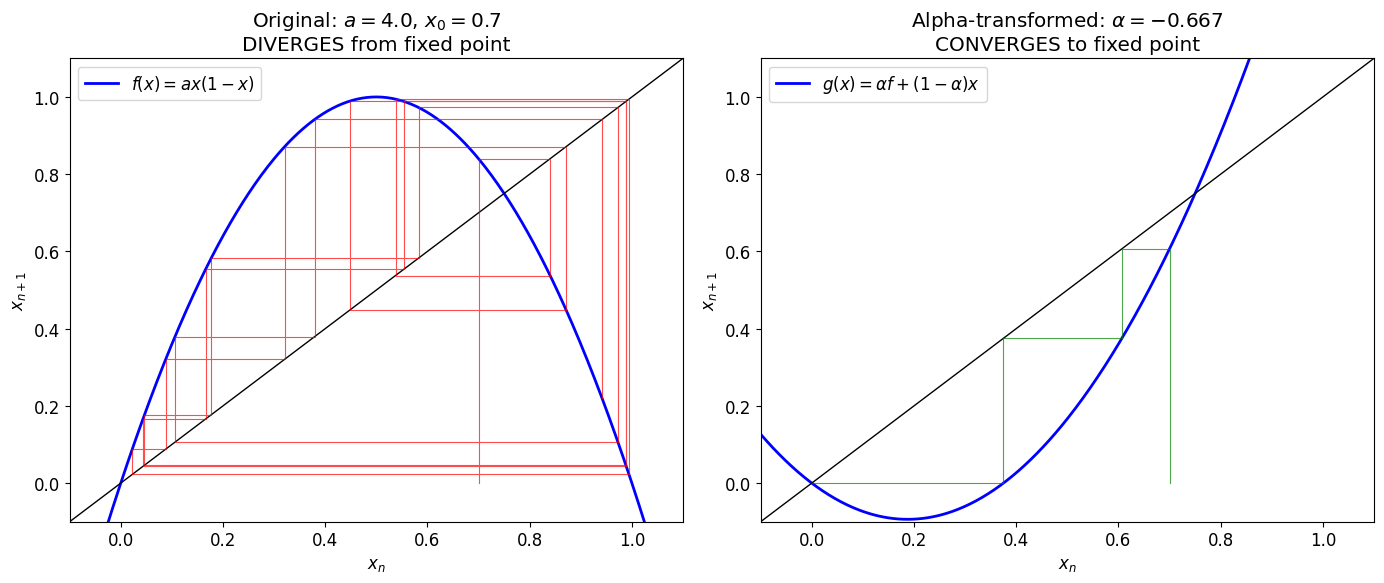

In [2]:
a = 4.0
x0 = 0.7

# Compute optimal alpha (restrict domain to [0,1] for logistic map)
alpha, info = compute_optimal_alpha(logistic, a, x_domain=(0.0, 1.0))
print(f"Optimal alpha = {alpha:.4f}")
print(f"  Method: {info['method']}, df_max = {info['df_max']}, df_min = {info['df_min']}")

# Cobweb data
Ix_orig, Iy_orig = cobweb_data(logistic, a, x0, n_iter=20)
Ix_trans, Iy_trans = cobweb_data(logistic, a, x0, n_iter=20, alpha=alpha)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
lx = np.linspace(-0.1, 1.1, 500)

# Original
ax1.plot(lx, logistic(a, lx), 'b-', lw=2, label=r'$f(x) = ax(1-x)$')
ax1.plot(lx, lx, 'k-', lw=1)
ax1.plot(Ix_orig, Iy_orig, 'r-', lw=0.8, alpha=0.7)
ax1.set_xlabel(r'$x_n$')
ax1.set_ylabel(r'$x_{n+1}$')
ax1.set_title(f'Original: $a={a}$, $x_0={x0}$\nDIVERGES from fixed point')
ax1.set_xlim(-0.1, 1.1)
ax1.set_ylim(-0.1, 1.1)
ax1.legend()

# Transformed
ly_t = alpha * logistic(a, lx) + (1 - alpha) * lx
ax2.plot(lx, ly_t, 'b-', lw=2, label=rf'$g(x) = \alpha f + (1-\alpha)x$')
ax2.plot(lx, lx, 'k-', lw=1)
ax2.plot(Ix_trans, Iy_trans, 'g-', lw=0.8, alpha=0.7)
ax2.set_xlabel(r'$x_n$')
ax2.set_ylabel(r'$x_{n+1}$')
ax2.set_title(rf'Alpha-transformed: $\alpha={alpha:.3f}$' + '\nCONVERGES to fixed point')
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

### 4.2 Bifurcation Diagrams: Original vs. Transformed

The bifurcation diagram shows the long-term behavior of the logistic map as the parameter $a$ varies. The alpha-transform should collapse the period-doubling cascade back to a fixed point.

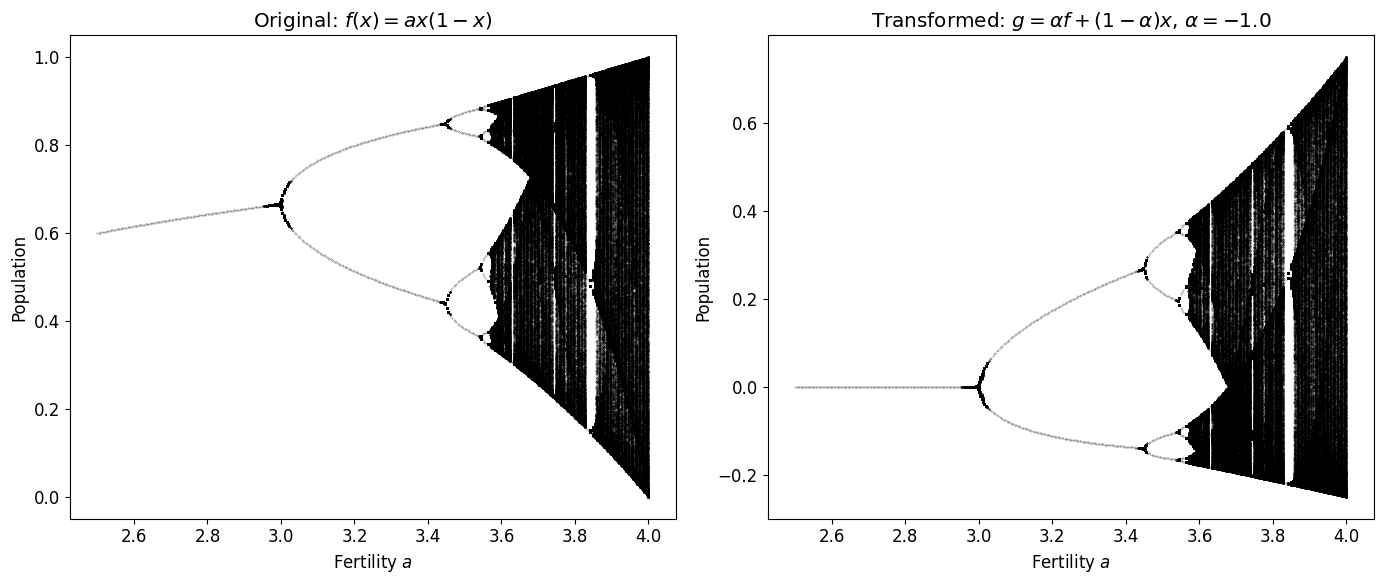

In [3]:
a_range = np.linspace(2.5, 4.0, 400)
x0_samples = np.linspace(0.1, 0.9, 30)
alpha_bif = -1.0  # Fixed alpha for comparison (as in original scripts)

# Original bifurcation
a_orig, x_orig = compute_bifurcation(logistic, a_range, x0_samples, n_iter=500, n_discard=400)
# Transformed bifurcation
a_trans, x_trans = compute_bifurcation_transformed(logistic, alpha_bif, a_range, x0_samples, n_iter=500, n_discard=400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(a_orig, x_orig, s=0.1, c='black', alpha=0.5)
ax1.set_xlabel('Fertility $a$')
ax1.set_ylabel('Population')
ax1.set_title('Original: $f(x) = ax(1-x)$')

ax2.scatter(a_trans, x_trans, s=0.1, c='black', alpha=0.5)
ax2.set_xlabel('Fertility $a$')
ax2.set_ylabel('Population')
ax2.set_title(rf'Transformed: $g = \alpha f + (1-\alpha)x$, $\alpha = {alpha_bif}$')

plt.tight_layout()
plt.show()

## 5. Part II — Eigenstates as Fixed Points

### 5.1 The Projective Fixed-Point Argument

In **projective Hilbert space** $\mathbb{P}(\mathcal{H})$ — the space of rays $[|\psi\rangle]$ where $|\psi\rangle \sim c|\psi\rangle$ — the eigenvalue equation $\hat{A}|\psi\rangle = \lambda|\psi\rangle$ states that $[|\psi\rangle]$ is a **fixed point** of the projective action of $\hat{A}$.

Define the projective map:

$$\Pi_A : [|\psi\rangle] \mapsto \left[\frac{\hat{A}|\psi\rangle}{\|\hat{A}|\psi\rangle\|}\right]$$

Then $[|\psi_k\rangle]$ is a fixed point of $\Pi_A$ if and only if $|\psi_k\rangle$ is an eigenstate of $\hat{A}$.

The **stability** of these fixed points is determined by the eigenvalue ratios $|\lambda_k / \lambda_{\max}|$:
- The eigenstate with largest $|\lambda|$ is the **attracting** fixed point of $\Pi_A$
- All other eigenstates are **repelling** (analogous to unstable fixed points)

**This is not just an analogy — it is the mathematical content of power iteration** [Ref 6, Ch. 25].

### 5.2 Inverse Power Iteration as Fixed-Point Iteration with Shift

Inverse power iteration with shift $\sigma$ uses $(\hat{A} - \sigma I)^{-1}$ as the iterating operator. This transforms the eigenvalue landscape: the eigenstate nearest $\sigma$ becomes the **dominant** (attracting) fixed point, because its transformed eigenvalue $1/(\lambda_k - \sigma)$ is largest.

This is precisely a **spectral shift** — changing which fixed point is stable, analogous to the alpha-transform changing which fixed point of the logistic map is attracting.

In [4]:
# Harmonic oscillator eigenvalues via matrix diagonalization
N = 500
x_grid = np.linspace(-8, 8, N)

eigenvalues, eigenvectors = solve_eigenstates(harmonic, x_grid, n_states=8)
exact = np.arange(8) + 0.5

print("Harmonic oscillator eigenvalues:")
print(f"{'n':>3}  {'Computed':>12}  {'Exact':>8}  {'Error':>10}")
for i in range(8):
    print(f"{i:3d}  {eigenvalues[i]:12.6f}  {exact[i]:8.1f}  {abs(eigenvalues[i] - exact[i]):10.2e}")

Harmonic oscillator eigenvalues:
  n      Computed     Exact       Error
  0      0.499968       0.5    3.21e-05
  1      1.499839       1.5    1.61e-04
  2      2.499582       2.5    4.18e-04
  3      3.499197       3.5    8.03e-04
  4      4.498682       4.5    1.32e-03
  5      5.498039       5.5    1.96e-03
  6      6.497268       6.5    2.73e-03
  7      7.496368       7.5    3.63e-03


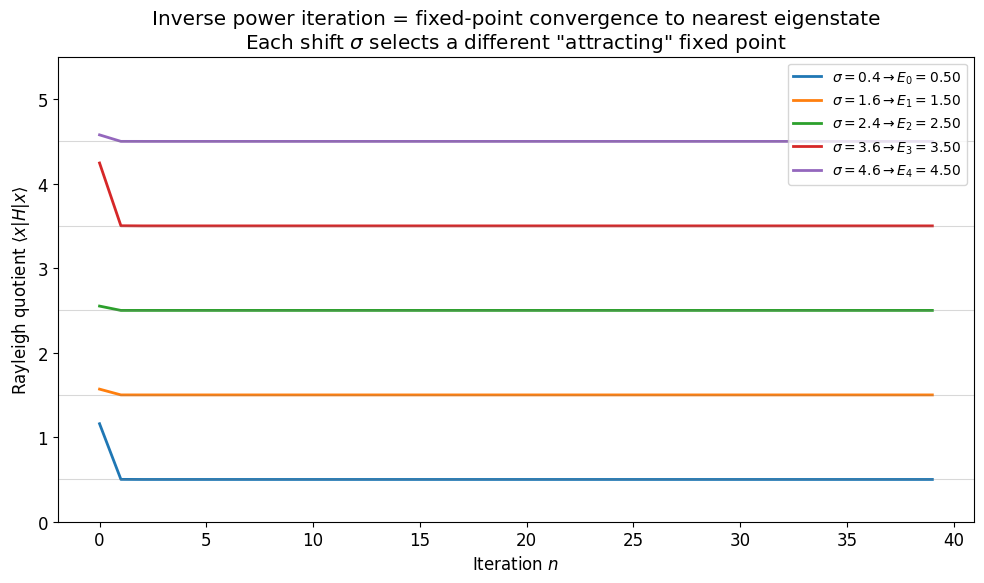

In [5]:
# Inverse power iteration: convergence to different eigenstates via shift
H = discretize_hamiltonian(harmonic, x_grid)
evals_full = eigh(H, eigvals_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
shifts = [0.4, 1.6, 2.4, 3.6, 4.6]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for sigma, color in zip(shifts, colors):
    rq = inverse_power_iteration(H, sigma, n_iter=40)
    nearest_idx = np.argmin(np.abs(evals_full - sigma))
    nearest_E = evals_full[nearest_idx]
    ax.plot(rq, color=color, lw=2,
            label=rf'$\sigma={sigma:.1f} \to E_{nearest_idx}={nearest_E:.2f}$')

for i in range(5):
    ax.axhline(evals_full[i], color='gray', alpha=0.3, lw=0.8)

ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Rayleigh quotient $\\langle x|H|x\\rangle$')
ax.set_title('Inverse power iteration = fixed-point convergence to nearest eigenstate\n'
             'Each shift $\\sigma$ selects a different "attracting" fixed point')
ax.legend(fontsize=10)
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

### 5.3 Alpha-Transform as Eigenstate Selector

Instead of a spectral shift, we can use the alpha-transform on the normalized power iteration:

$$|x_{n+1}\rangle = \alpha \frac{\hat{A}|x_n\rangle}{\|\hat{A}|x_n\rangle\|} + (1-\alpha)|x_n\rangle$$

Different values of $\alpha$ change the fixed-point stability landscape in projective space, potentially allowing access to eigenstates that power iteration alone cannot reach.

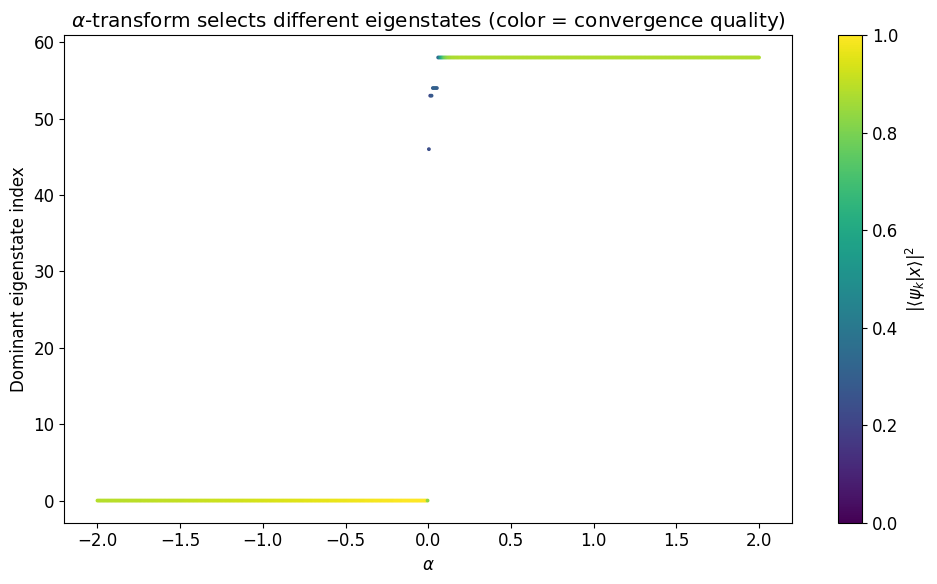

In [6]:
# Alpha-scan: which eigenstate does the iteration converge to for each alpha?
N_small = 60
x_small = np.linspace(-5, 5, N_small)
H_small = discretize_hamiltonian(harmonic, x_small)

alphas = np.linspace(-2.0, 2.0, 500)
rng = np.random.default_rng(7)
x0 = rng.standard_normal(N_small)

dom, quality, ev_small = alpha_eigenstate_scan(H_small, x0, alphas, n_iter=500)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(alphas, dom, c=quality, cmap='viridis', s=3, vmin=0, vmax=1)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Dominant eigenstate index')
ax.set_title(r'$\alpha$-transform selects different eigenstates (color = convergence quality)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$|\langle\psi_k|x\rangle|^2$')
plt.tight_layout()
plt.show()

## 6. Part III — Turbiner's Riccati-Bloch Method as Dynamical System

### 6.1 The Riccati-Bloch Equation

Using Turbiner's substitution $\psi(x) = \exp\!\left(-\int^x y(t)\,dt\right)$, the Schrödinger equation becomes [Ref 1]:

$$y'(x) = y(x)^2 - 2V(x) + 2E$$

This is a **Riccati equation** — a first-order nonlinear ODE. The critical observation:

- At an eigenvalue $E = E_n$: the trajectory $y(x)$ remains **bounded** for all $x$
- Away from an eigenvalue: $y(x)$ develops a **Riccati singularity** (diverges at finite $x$)

This means **eigenvalues are the parameter values for which a nonlinear dynamical system has bounded (non-divergent) trajectories**. This is a direct analog of how, in bifurcation theory, certain parameter values separate qualitatively different dynamical behaviors.

### 6.2 Spectral Scanning via the Shooting Method

We sweep $E$ and for each trial energy integrate the Schrödinger equation forward from $x = 0$ with appropriate boundary conditions. At eigenvalues, $\psi(x_{\max}) \to 0$; elsewhere it diverges.

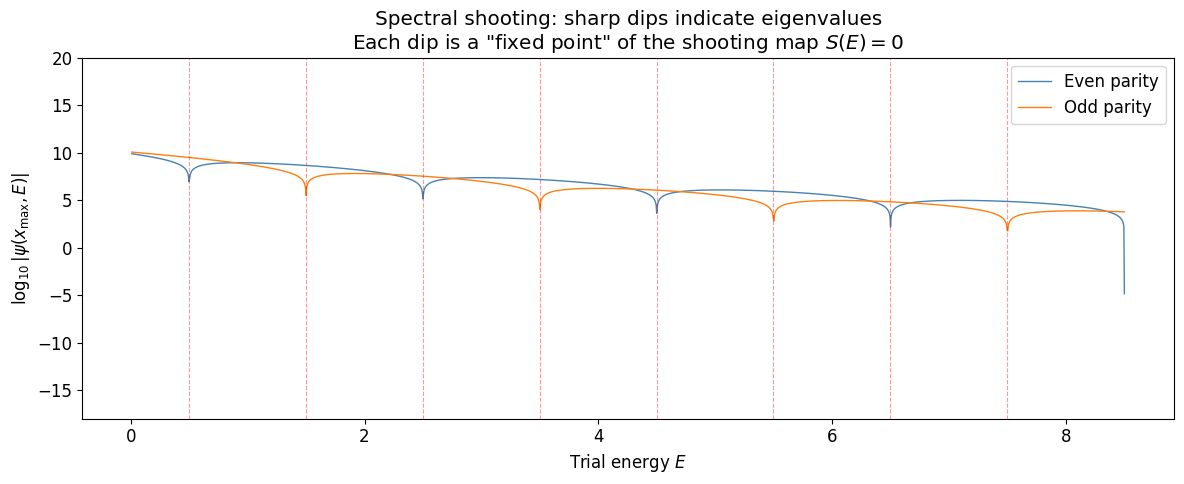

In [7]:
# Spectral scan: find eigenvalues as zeros of the shooting function
E_range = np.linspace(0.01, 8.5, 2000)
x_span = (0.0, 7.0)

psi_even = spectral_scan(harmonic, E_range, x_span, parity='even')
psi_odd = spectral_scan(harmonic, E_range, x_span, parity='odd')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(E_range, np.log10(np.abs(psi_even) + 1e-20), 'steelblue', lw=1.0, label='Even parity')
ax.plot(E_range, np.log10(np.abs(psi_odd) + 1e-20), '#ff7f0e', lw=1.0, label='Odd parity')

for i in range(8):
    ev = evals_full[i]
    if ev <= 8.5:
        ax.axvline(ev, color='red', alpha=0.4, lw=0.8, ls='--')

ax.set_xlabel('Trial energy $E$')
ax.set_ylabel(r'$\log_{10}|\psi(x_{\max}, E)|$')
ax.set_title('Spectral shooting: sharp dips indicate eigenvalues\n'
             r'Each dip is a "fixed point" of the shooting map $S(E) = 0$')
ax.legend()
ax.set_ylim(-18, 20)
plt.tight_layout()
plt.show()

### 6.3 Riccati Trajectories: Bounded if and only if $E = E_n$

The Riccati-Bloch equation $y' = y^2 - 2V + 2E$ gives bounded $y(x)$ only at eigenvalues. This is the dynamical-systems perspective on quantization: **eigenvalues are selected by a global regularity condition on a nonlinear flow.**

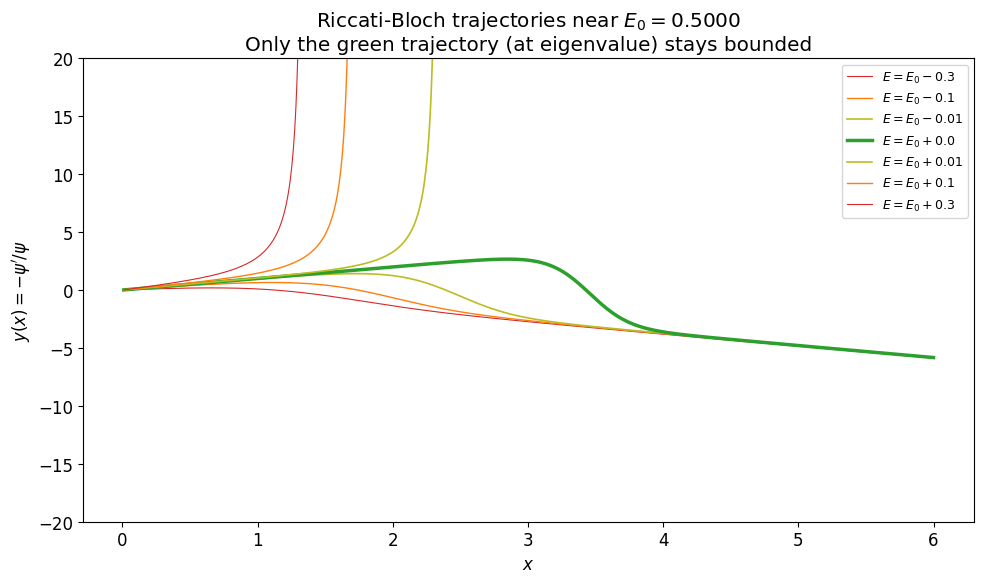

In [8]:
# Riccati trajectories near the ground state energy
E_exact = evals_full[0]

offsets = [-0.3, -0.1, -0.01, 0.0, 0.01, 0.1, 0.3]
colors_r = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#bcbd22', '#ff7f0e', '#d62728']
widths = [0.8, 1.0, 1.2, 2.5, 1.2, 1.0, 0.8]

fig, ax = plt.subplots(figsize=(10, 6))
for offset, color, w in zip(offsets, colors_r, widths):
    E_trial = E_exact + offset
    sol = riccati_solve(harmonic, E_trial, (0.01, 6.0), y0=0.01)
    label = rf'$E = E_0 {"+" if offset >= 0 else ""}{offset}$'
    ax.plot(sol.t, sol.y[0], color=color, lw=w, label=label)

ax.set_xlabel('$x$')
ax.set_ylabel(r"$y(x) = -\psi'/\psi$")
ax.set_title(f'Riccati-Bloch trajectories near $E_0 = {E_exact:.4f}$\n'
             'Only the green trajectory (at eigenvalue) stays bounded')
ax.set_ylim(-20, 20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Alpha-Relaxed Riccati: Stabilizing Excited States

The alpha-transform can be applied to the discretized Riccati equation:

$$y_{n+1} = \alpha\left[y_n + h\left(y_n^2 - 2V(x_n) + 2E\right)\right] + (1-\alpha)y_n$$

This is a direct bridge from the 2017 alpha-transform work to Turbiner's framework. The hypothesis: **different $\alpha$ values can stabilize Riccati trajectories for excited states that are normally repulsive** — just as the alpha-transform stabilizes unstable fixed points of the logistic map.

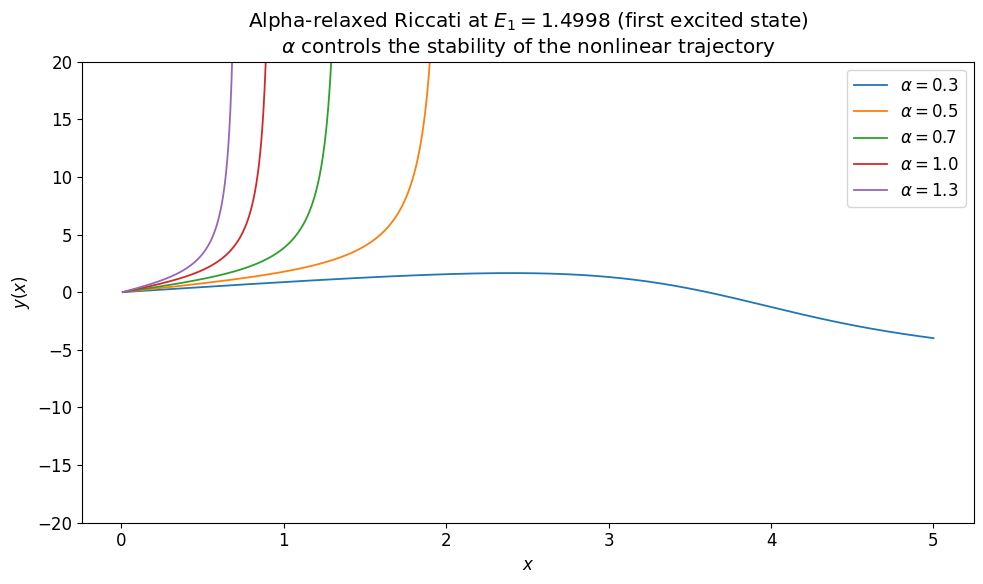

In [9]:
# Alpha-relaxed Riccati for the first excited state
E1 = evals_full[1]
x_alpha_grid = np.linspace(0.01, 5.0, 1500)

alphas_demo = [0.3, 0.5, 0.7, 1.0, 1.3]
colors_a = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(10, 6))
for alpha_val, color in zip(alphas_demo, colors_a):
    y_traj = riccati_alpha(harmonic, E1, x_alpha_grid, y0=0.01, alpha=alpha_val)
    ax.plot(x_alpha_grid, y_traj, color=color, lw=1.3, label=rf'$\alpha = {alpha_val}$')

ax.set_xlabel('$x$')
ax.set_ylabel('$y(x)$')
ax.set_title(rf'Alpha-relaxed Riccati at $E_1 = {E1:.4f}$ (first excited state)' + '\n'
             r'$\alpha$ controls the stability of the nonlinear trajectory')
ax.set_ylim(-20, 20)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Part IV — Eigenvalue Detection via Fixed-Point Methods

### 7.1 Automated Eigenvalue Detection

We can detect eigenvalues by finding the minima of $|\psi(x_{\max}, E)|$ — these are the values of $E$ where the shooting map $S(E) = \psi(x_{\max})$ has a zero (fixed point). This works for arbitrary potentials, including those without known analytic solutions.

In [10]:
# Eigenvalue detection for the harmonic oscillator
E_fine = np.linspace(0.01, 8.0, 5000)
E_detected = detect_eigenvalues(harmonic, E_fine, x_span=(0.0, 7.0), order=20)

print("Eigenvalue detection via Riccati/shooting fixed-point method:")
print(f"{'Detected':>12}  {'Exact (matrix)':>14}  {'Exact (analytic)':>16}  {'Error':>10}")
for E_det in E_detected:
    near_idx = np.argmin(np.abs(evals_full - E_det))
    E_mat = evals_full[near_idx]
    E_ana = near_idx + 0.5
    print(f"{E_det:12.5f}  {E_mat:14.5f}  {E_ana:16.1f}  {abs(E_det - E_ana):10.2e}")

Eigenvalue detection via Riccati/shooting fixed-point method:
    Detected  Exact (matrix)  Exact (analytic)       Error
     0.50068         0.49997               0.5    6.84e-04
     1.49963         1.49984               1.5    3.66e-04
     2.50018         2.49958               2.5    1.82e-04
     3.50073         3.49920               3.5    7.30e-04
     4.49968         4.49868               4.5    3.20e-04
     5.50023         5.49804               5.5    2.28e-04
     6.50078         6.49727               6.5    7.76e-04
     7.49973         7.49637               7.5    2.74e-04


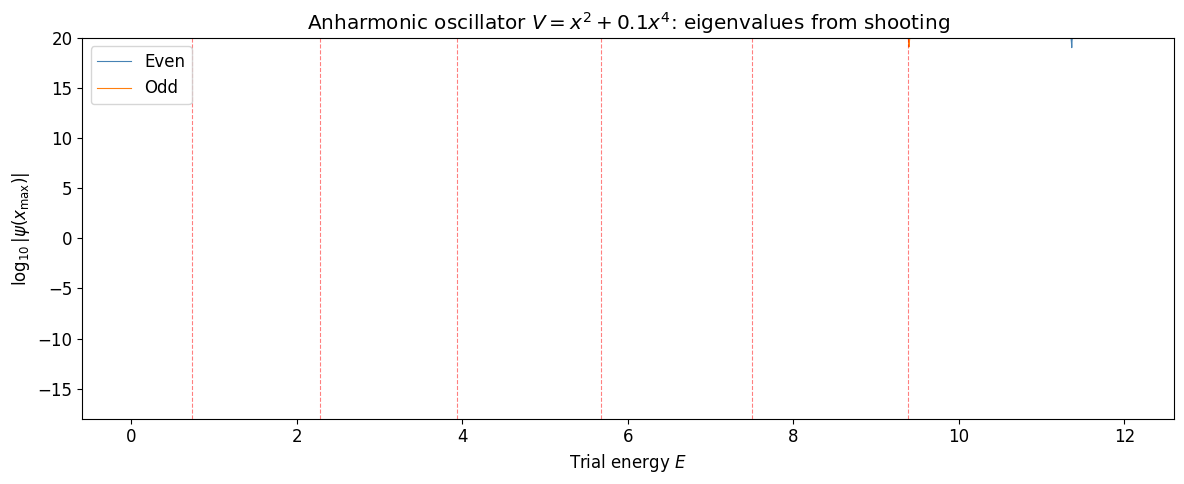


Anharmonic oscillator eigenvalue detection:
    Detected   Matrix diag       Error
      0.7416        0.7408    7.99e-04
      2.2809        2.2819    1.02e-03
      3.9320        3.9316    4.01e-04
      5.6752        5.6735    1.65e-03
      7.5023        7.4963    5.96e-03
      9.3973        9.3917    5.61e-03
     11.3643       11.3533    1.10e-02


In [11]:
# Now for the anharmonic oscillator — no analytic solution exists
V_anh = lambda x: anharmonic(x, g=0.1)
evals_anh = eigh(discretize_hamiltonian(V_anh, x_grid), eigvals_only=True)

E_anh_range = np.linspace(0.01, 12.0, 3000)
E_anh_detected = detect_eigenvalues(V_anh, E_anh_range, x_span=(0.0, 7.0), order=10)

psi_anh_even = spectral_scan(V_anh, E_anh_range, (0.0, 7.0), parity='even')
psi_anh_odd = spectral_scan(V_anh, E_anh_range, (0.0, 7.0), parity='odd')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(E_anh_range, np.log10(np.abs(psi_anh_even) + 1e-20), 'steelblue', lw=0.8, label='Even')
ax.plot(E_anh_range, np.log10(np.abs(psi_anh_odd) + 1e-20), '#ff7f0e', lw=0.8, label='Odd')
for i in range(6):
    ev = evals_anh[i]
    if ev <= 12.0:
        ax.axvline(ev, color='red', alpha=0.5, lw=0.8, ls='--')
ax.set_xlabel('Trial energy $E$')
ax.set_ylabel(r'$\log_{10}|\psi(x_{\max})|$')
ax.set_title('Anharmonic oscillator $V = x^2 + 0.1x^4$: eigenvalues from shooting')
ax.legend()
ax.set_ylim(-18, 20)
plt.tight_layout()
plt.show()

print("\nAnharmonic oscillator eigenvalue detection:")
print(f"{'Detected':>12}  {'Matrix diag':>12}  {'Error':>10}")
for E_det in E_anh_detected:
    near_idx = np.argmin(np.abs(evals_anh - E_det))
    print(f"{E_det:12.4f}  {evals_anh[near_idx]:12.4f}  {abs(E_det - evals_anh[near_idx]):10.2e}")

## 8. Assessment: Is There Something Here?

### 8.1 What Is Established

The connection between eigenstates and fixed points is **mathematically rigorous** in these senses:

1. **Projective fixed points**: Eigenstates are exactly the fixed points of the operator's projective action on $\mathbb{P}(\mathcal{H})$. This is not a conjecture — it's a theorem. Power iteration and inverse power iteration are literal fixed-point iterations exploiting this fact [Ref 6].

2. **Riccati regularity**: Via Turbiner's substitution, eigenvalues are exactly the parameter values for which a nonlinear ODE (the Riccati-Bloch equation) has globally bounded solutions [Ref 1]. This recasts quantization as a **global regularity condition** on a dynamical system.

3. **RG fixed points**: Wilson's renormalization group already treats phase transitions as fixed points of block-spin maps [Ref 8], and Migdal-Kadanoff approximations reduce lattice gauge theory to iterated maps whose fixed points encode critical behavior [Ref 9, 10].

### 8.2 What Is Open / Potentially Novel

1. **Alpha-transform applied to Riccati**: Applying the alpha-relaxation to Turbiner's discretized Riccati equation is (as far as we can determine) not in the literature. If different $\alpha$ values can selectively stabilize excited-state Riccati trajectories, this could yield a new class of spectral algorithms.

2. **Spectral bifurcation diagrams**: Plotting the long-term behavior of the Riccati iteration as a function of trial energy $E$ — analogous to the bifurcation diagram of the logistic map as a function of $a$ — is a novel visualization. Eigenvalues appear as "bifurcation points" separating qualitatively different dynamics.

3. **Connection to SCN/diagram filtering (from Nullified)**: In the Nullified project, self-referential Feynman diagrams were identified and filtered. In fixed-point language, Dyson resummation is an iterated map $G = G_0 + G_0 \Sigma G$ whose fixed point is the dressed propagator. SCN says: certain nested iterations should be nullified. This is a statement about the **domain** of the fixed-point map.

4. **Multi-dimensional generalization**: The 1D alpha-transform $g = \alpha f + (1-\alpha)x$ generalizes naturally to operators on Hilbert space. The full stability analysis in the operator case — where eigenvalues can be complex and the state space is infinite-dimensional — is underexplored.

### 8.3 What Would Need To Be True

For this program to yield genuinely new science, at least one of these would need to hold:

- The alpha-Riccati method converges faster or handles more difficult potentials than existing spectral methods (Numerov, DVR, complex scaling)
- The fixed-point perspective reveals new analytical results about spectra (e.g., bounds or asymptotics)
- The connection to RG fixed points extends beyond analogy to concrete calculations

### 8.4 Verdict

**Promising but unproven.** The mathematical connections are real and well-grounded. The alpha-transform applied to Turbiner's framework is novel and testable. The question is whether it yields practical advantages or theoretical insights beyond what existing methods provide. The next steps should focus on **concrete benchmarks** against known spectral methods and **analytical investigation** of the alpha-Riccati convergence properties.

## 9. Next Steps

### Immediate
- [ ] Benchmark alpha-Riccati convergence rate vs. standard Numerov method
- [ ] Characterize the $\alpha$-parameter space systematically: which $\alpha$ stabilizes which eigenstate?
- [ ] Test on harder potentials: double well (tunneling), Morse (finite bound states), Coulomb (singular)

### Medium-term
- [ ] Analytical investigation: derive convergence conditions for alpha-Riccati
- [ ] Connect to Turbiner's quasi-exactly-solvable potentials [Ref 2, 3]
- [ ] Explore the Riccati spectral bifurcation diagram for non-harmonic potentials

### Long-term
- [ ] Extend to multi-dimensional Schrödinger equation (Hartree-Fock, DFT)
- [ ] Investigate connection to renormalization group fixed points quantitatively
- [ ] Explore implications for superdeterministic interpretations (if the eigenvalue-fixed-point correspondence constrains the space of allowed theories)